# 🧠 02_Algorithm from Scratch: Self-Attention & Masked Attention 밑바닥부터 구현하기

이 노트북은 `01_theory.md`에서 배운 어텐션 공식 $Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$ 을 파이토치(PyTorch)의 내장 어텐션 모듈 없이 순수 행렬 곱셈만으로 직접 구현해 보는 실습입니다.

> **목표 1**: 외계어 같은 수식을 코드로 치환해 보면서, 단어들이 서로를 어떻게 스캔하고 정보를 섞는지 직관적으로 확인하기!
> **목표 2 [심화]**: 챗GPT가 글을 순차적으로 생성할 때, 미래를 커닝하지 못하게 막는 **마스크드 어텐션(Masked Attention)**의 수학적 꼼수 시뮬레이션하기!

In [1]:
import matplotlib.pyplot as plt
import os

if os.name == 'nt':
    plt.rc('font', family='Malgun Gothic') # 윈도우 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

## 1. 가짜 데이터(문장 임베딩) 준비
이전 실습(Embeddings)에서 문장을 단어 벡터로 변환하는 것을 배웠습니다. 
여기서는 `"The cat sits"` 라는 3단어로 이루어진 문장이 이미 4차원 임베딩 벡터로 변환되어 들어왔다고 가정합니다.

In [2]:
import torch
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

# 시퀀스 길이(단어 수) = 3, 임베딩 차원 = 4
seq_len = 3
d_model = 4

# "The cat sits" 문장의 단어 임베딩 (임의의 값)
words = ["The", "cat", "sits"]
X = torch.tensor([
    [1.0, 0.0, 1.0, 0.0],  # "The"의 임베딩
    [0.0, 2.0, 0.0, 2.0],  # "cat"의 임베딩
    [1.0, 1.0, 1.0, 1.0]   # "sits"의 임베딩
])

print("입력 문장 임베딩 행렬 X (크기: 3x4):\n", X)

입력 문장 임베딩 행렬 X (크기: 3x4):
 tensor([[1., 0., 1., 0.],
        [0., 2., 0., 2.],
        [1., 1., 1., 1.]])


## 2. Query, Key, Value 행렬 만들기
하나의 입력 $X$로부터 각 단어의 각자 다른 역할(Q, K, V)을 뽑아내기 위해, 가중치 행렬 $W_q, W_k, W_v$를 곱해줍니다. 
실제 모델에서는 이 가중치 행렬들이 학습되는 파라미터입니다.

In [3]:
# Q, K, V 차원은 통상적으로 원래 차원과 같거나 더 작게 만듭니다. 여기서는 3차원으로 축소합니다.
d_k = 3  # Q, K, V의 차원 수

torch.manual_seed(42) # 재현성을 위해 시드 고정

# 가중치 행렬 무작위 초기화 (크기: 4x3)
W_q = torch.randn(d_model, d_k)
W_k = torch.randn(d_model, d_k)
W_v = torch.randn(d_model, d_k)

# 행렬 곱셈(matmul)으로 Q, K, V 생성
Q = torch.matmul(X, W_q)  # (3x4) x (4x3) = (3x3)
K = torch.matmul(X, W_k)  # (3x3)
V = torch.matmul(X, W_v)  # (3x3)

print("Query 행렬 (Q):\n", Q)
print("\nKey 행렬 (K):\n", K)

Query 행렬 (Q):
 tensor([[ 2.5449, -0.5092,  0.6961],
        [ 0.9954, -1.1759,  1.2461],
        [ 3.0426, -1.0971,  1.3191]])

Key 행렬 (K):
 tensor([[ 0.3445, -2.4404,  0.3636],
        [ 3.2886,  1.9888,  3.2243],
        [ 1.9887, -1.4460,  1.9757]])


## 3. 일반적인 어텐션 스코어 계산 (Self-Attention)
이제 내 단어의 질문(Q)과 다른 단어들의 이름표(K)를 내적(Dot-product)해서 유사도를 구하고 스케일링을 합니다.

In [4]:
# 1. Q와 K의 전치행렬(Transpose)을 내적
scores = torch.matmul(Q, K.transpose(-2, -1))  # 크기: (3x3)

# 2. 차원의 제곱근으로 스케일링
scaled_scores = scores / math.sqrt(d_k)

print("==== 스케일링 후 Raw Scores (BERT 방식) ====")
print(scaled_scores)

==== 스케일링 후 Raw Scores (BERT 방식) ====
tensor([[1.3697, 5.5431, 4.1412],
        [2.1163, 2.8593, 3.5460],
        [2.4278, 6.9728, 5.9142]])


## 🌟 4. [심화] Masked Attention 시뮬레이션 (GPT 방식)
GPT 모델은 텍스트를 생성할 때 미래를 보지 않아야 합니다.
예를 들어, 'The'를 처리할 때는 'cat', 'sits'를 보지 말아야 하고, 'cat'을 처리할 때는 'sits'를 보지 말아야 합니다.

**원리**: PyTorch의 하삼각행렬(`tril`)을 만들어서, 미래(우상단)의 인덱스 위치에 매우 작은 값(`-1e9`)을 덮어씌웁니다.

In [5]:
# 1. (3x3) 크기의 하삼각행렬 마스크 생성 (미래는 0, 과거/현재는 1)
mask = torch.tril(torch.ones(seq_len, seq_len))
print("==== 미래를 가리는 Mask ====")
print(mask)

# 2. 마스크가 0인 부분(미래)을 -무한대(-1e9)로 덮어씌움
masked_scores = scaled_scores.masked_fill(mask == 0, -1e9)

print("\n==== 마스킹이 적용된 Scores ====")
print(masked_scores)
print("💡 미래 시점의 값들이 -1,000,000,000 으로 죽어버렸습니다!")

==== 미래를 가리는 Mask ====
tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

==== 마스킹이 적용된 Scores ====


tensor([[ 1.3697e+00, -1.0000e+09, -1.0000e+09],
        [ 2.1163e+00,  2.8593e+00, -1.0000e+09],
        [ 2.4278e+00,  6.9728e+00,  5.9142e+00]])
💡 미래 시점의 값들이 -1,000,000,000 으로 죽어버렸습니다!


## 5. 확률로 변환 (Softmax)
점수를 Softmax 함수에 통과시켜 1.0(100%) 확률로 만듭니다. `-무한대`가 들어간 자리는 과연 어떻게 변할까요?

==== 어텐션 가중치 (Attention Weights) ====
tensor([[1.0000, 0.0000, 0.0000],
        [0.3224, 0.6776, 0.0000],
        [0.0078, 0.7366, 0.2556]])


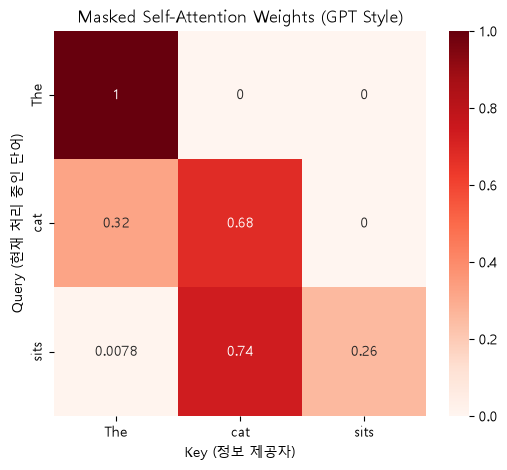

💡 [핵심 깨달음]:
'The' (첫 줄)는 오직 'The' 정보만 100% 참조합니다.
'cat' (두 번째 줄)는 'The'와 'cat' 정보만 참조하고, 미래의 'sits'는 0%로 완벽히 차단합니다.
이것이 바로 챗GPT가 단어를 순차적으로 생성해낼 수 있는 'Masked Attention'의 위대한 수학적 꼼수입니다!


In [6]:
# 행 단위로 Softmax 적용
attention_weights = F.softmax(masked_scores, dim=-1)

print("==== 어텐션 가중치 (Attention Weights) ====")
print(attention_weights)

# 히트맵 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(attention_weights.detach().numpy(), annot=True, cmap="Reds", 
            xticklabels=words, yticklabels=words)
plt.title("Masked Self-Attention Weights (GPT Style)")
plt.xlabel("Key (정보 제공자)")
plt.ylabel("Query (현재 처리 중인 단어)")
plt.show()

print("💡 [핵심 깨달음]:")
print("'The' (첫 줄)는 오직 'The' 정보만 100% 참조합니다.")
print("'cat' (두 번째 줄)는 'The'와 'cat' 정보만 참조하고, 미래의 'sits'는 0%로 완벽히 차단합니다.")
print("이것이 바로 챗GPT가 단어를 순차적으로 생성해낼 수 있는 'Masked Attention'의 위대한 수학적 꼼수입니다!")

## 6. 최종 문맥 벡터(Context Vector) 추출
구해진 가중치를 Value 행렬($V$)과 곱해주면 끝입니다.

In [7]:
output = torch.matmul(attention_weights, V)
print("==== 최종 출력 벡터 (Contextualized Embeddings) ====")
print(output)
print("이 벡터들은 이제 미래의 단어(정답)를 커닝하지 않고 온전히 과거 문맥만 반영된 안전한 상태입니다.")

==== 최종 출력 벡터 (Contextualized Embeddings) ====
tensor([[ 0.2730,  0.7852,  0.6559],
        [ 0.9359, -1.1910, -0.2798],
        [ 1.1535, -1.6353, -0.4538]])
이 벡터들은 이제 미래의 단어(정답)를 커닝하지 않고 온전히 과거 문맥만 반영된 안전한 상태입니다.


## 🚀 7. [심화] Multi-Head Attention 구현하기
트랜스포머의 진짜 힘은 어텐션을 여러 갈래(Head)로 나누어 연산하는 데 있습니다.
동일한 정보를 여러 시각(문법, 지시어, 문맥 등)에서 바라보고 나중에 합치는 과정을 실습합니다.

In [8]:
# 1. 헤드(Head) 개수 설정
num_heads = 2
d_model = 4 # 원래 임베딩 차원
d_k_per_head = d_model // num_heads # 각 헤드가 담당할 차원 (2)

print(f"원래 차원 {d_model}을 {num_heads}개의 헤드로 나눕니다. 각 헤드는 {d_k_per_head}차원을 가집니다.")

# 2. 입력을 여러 헤드로 쪼개기 (분할)
# 실제로는 Linear Layer를 통과시킨 후 reshape/view를 통해 쪼갭니다.
# Q 행렬 (3x4) -> (3 x 2 x 2) -> (2 x 3 x 2) : (Head 수, 시퀀스 길이, 헤드당 차원)
W_q_multi = torch.randn(d_model, d_model)
Q_multi = torch.matmul(X, W_q_multi) # (3, 4)
Q_heads = Q_multi.view(seq_len, num_heads, d_k_per_head).transpose(0, 1) # (2, 3, 2)

W_k_multi = torch.randn(d_model, d_model)
K_multi = torch.matmul(X, W_k_multi)
K_heads = K_multi.view(seq_len, num_heads, d_k_per_head).transpose(0, 1) # (2, 3, 2)

W_v_multi = torch.randn(d_model, d_model)
V_multi = torch.matmul(X, W_v_multi)
V_heads = V_multi.view(seq_len, num_heads, d_k_per_head).transpose(0, 1) # (2, 3, 2)

print("Q 행렬이 2개의 헤드로 나뉘었습니다. 형태:", Q_heads.shape)

원래 차원 4을 2개의 헤드로 나눕니다. 각 헤드는 2차원을 가집니다.
Q 행렬이 2개의 헤드로 나뉘었습니다. 형태: torch.Size([2, 3, 2])


In [9]:
# 3. 각 헤드별로 어텐션 스코어 계산 (병렬 처리)
# 행렬 연산의 브로드캐스팅 덕분에 반복문 없이 한 번에 계산됩니다.
scores_heads = torch.matmul(Q_heads, K_heads.transpose(-2, -1)) / math.sqrt(d_k_per_head) # (2, 3, 3)
attention_weights_heads = F.softmax(scores_heads, dim=-1)

# 4. 각 헤드별 문맥 벡터 생성
output_heads = torch.matmul(attention_weights_heads, V_heads) # (2, 3, 2)

# 5. 다시 하나로 합치기 (Concat)
# (Head 수, 시퀀스 길이, 차원) -> (시퀀스 길이, Head 수, 차원) -> (시퀀스 길이, 전체 차원)
output_concat = output_heads.transpose(0, 1).contiguous().view(seq_len, d_model) # (3, 4)

print("==== Multi-Head Attention 최종 출력 ====")
print(output_concat)
print("형태:", output_concat.shape)

==== Multi-Head Attention 최종 출력 ====
tensor([[-1.1122,  1.6254,  3.7771,  2.0103],
        [-1.6748,  1.0724,  5.7253,  3.0688],
        [-1.1425,  1.6194,  5.3203,  2.8474]])
형태: torch.Size([3, 4])


## 🤝 8. [심화] Cross-Attention 맛보기
지금까지는 Query, Key, Value가 모두 같은 입력(`X`)에서 나왔습니다 (Self-Attention).
번역기(Seq2Seq) 구조에서 디코더는 현재 번역 중인 단어(Query)를 가지고, 인코더가 압축해 둔 원본 문장의 단어들(Key, Value)을 참조합니다. 이를 Cross-Attention이라고 합니다.

In [10]:
# 인코더의 출력 (예: 한국어 원문 "고양이가 앉아있다"의 벡터)
encoder_output = torch.randn(5, 4) # 5단어, 4차원

# 디코더의 현재 상태 (예: 영어 번역 중 "The cat"까지 생성된 상태)
decoder_state = torch.randn(2, 4) # 2단어, 4차원

# Cross-Attention에서는 Query는 디코더에서, Key/Value는 인코더에서 옵니다.
W_q_cross = torch.randn(4, 3)
W_k_cross = torch.randn(4, 3)
W_v_cross = torch.randn(4, 3)

Q_cross = torch.matmul(decoder_state, W_q_cross) # (2, 3)
K_cross = torch.matmul(encoder_output, W_k_cross) # (5, 3)
V_cross = torch.matmul(encoder_output, W_v_cross) # (5, 3)

# 어텐션 스코어: 디코더의 2단어가 인코더의 5단어를 바라봅니다.
cross_scores = torch.matmul(Q_cross, K_cross.transpose(-2, -1)) / math.sqrt(3) # (2, 5)
cross_attn_weights = F.softmax(cross_scores, dim=-1)

print("==== Cross-Attention 가중치 형태 ====")
print(cross_attn_weights.shape, "-> 디코더의 2개 단어가 각각 인코더의 5개 단어에 가중치를 분배합니다.")

==== Cross-Attention 가중치 형태 ====
torch.Size([2, 5]) -> 디코더의 2개 단어가 각각 인코더의 5개 단어에 가중치를 분배합니다.


## 🗺️ 9. [심화] Positional Encoding (위치 정보 추가하기)
어텐션은 단어의 순서를 무시하고 계산합니다. 따라서 'The cat'이나 'cat The'나 동일하게 취급합니다.
이를 해결하기 위해 입력 벡터에 단어의 위치 정보(사인/코사인파)를 더해주는 것이 Positional Encoding입니다.

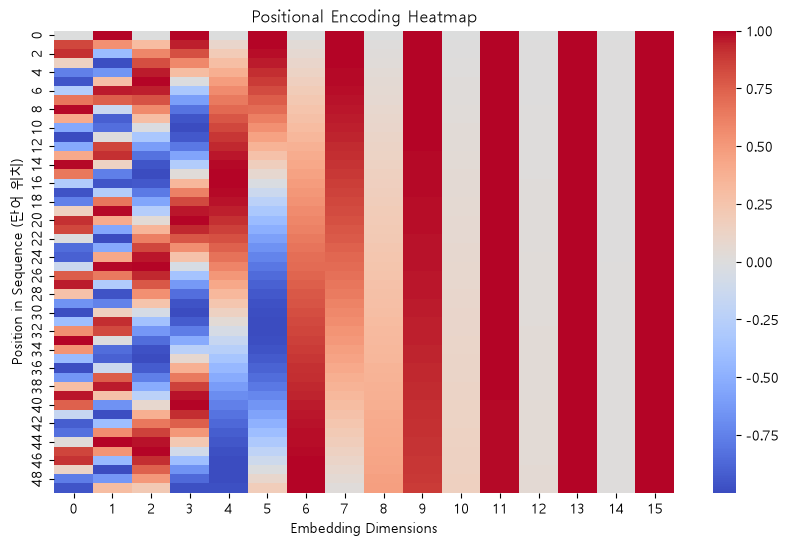

💡 단어의 위치(세로축)에 따라 각기 다른 패턴의 주파수 신호가 생성되어, 임베딩 벡터에 더해집니다.


In [11]:
import numpy as np

# 최대 시퀀스 길이 50, 임베딩 차원 16을 가정
max_seq_len = 50
d_model_pos = 16

position = np.arange(max_seq_len)[:, np.newaxis]
div_term = np.exp(np.arange(0, d_model_pos, 2) * -(math.log(10000.0) / d_model_pos))

pe = np.zeros((max_seq_len, d_model_pos))
pe[:, 0::2] = np.sin(position * div_term)
pe[:, 1::2] = np.cos(position * div_term)

plt.figure(figsize=(10, 6))
sns.heatmap(pe, cmap='coolwarm', cbar=True)
plt.title("Positional Encoding Heatmap")
plt.xlabel("Embedding Dimensions")
plt.ylabel("Position in Sequence (단어 위치)")
plt.show()

print("💡 단어의 위치(세로축)에 따라 각기 다른 패턴의 주파수 신호가 생성되어, 임베딩 벡터에 더해집니다.")